# Uses 'SampleData2.csv'

# Parallel Sets

In [3]:
import csv
import random
from random import randint

header = ['SubjID', 'Decision1', 'Bias1', 'Decision2', 'Bias2', 'Decision3', 'Bias3', 'HealthStatus']

data = []
d1 = 0; d2 = 0; d3 = 0
b1 = 0; b2 = 0; b3 = 0
health = 0
health_vals = [75, 80, 85, 90, 95, 100]

for i in range(1, 201):    
    d1 = randint(0, 5)
    d2 = randint(0, 5)
    d3 = randint(0, 5)
    
    b1 = randint(0, 1)
    b2 = randint(0, 1)
    b3 = randint(0, 1)
    
    health = random.choice(health_vals) 
    
    data.append([i, d1, b1, d2, b2, d3, b2, health])

with open('SampleData2.csv', 'w', encoding='UTF8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(data)

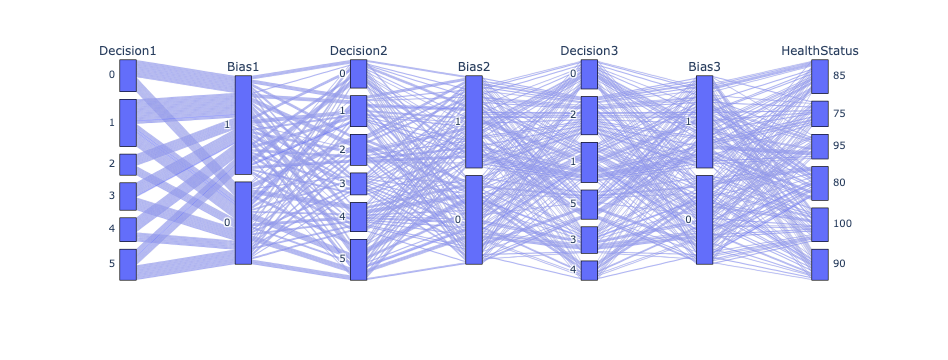

In [6]:
import pandas as pd
import numpy as np
import plotly.express as px

data = pd.read_csv("SampleData2.csv")
#data

fig = px.parallel_categories(data)
fig.show()

### Decision Codes:
0, 1, 2, 3 - North, South, East, West
<br>
4 - Shallow river crossing
<br>
5 - Gathering resources/supplies
<br>

### Bias:
1 - Single Evaluation (SE), 0 - Joint Evaluation (JE)

# StreamGraph

In [50]:
# lists
subjID_list = data["SubjID"].values.tolist()
d1_list = data["Decision1"].values.tolist()
d2_list = data["Decision2"].values.tolist()
d3_list = data["Decision3"].values.tolist()

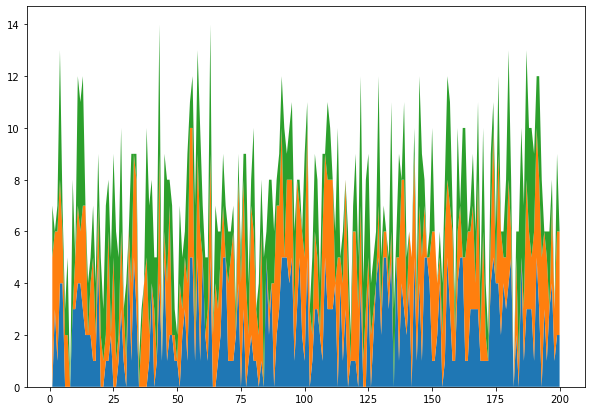

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

x = subjID_list
y = [d1_list, d2_list, d3_list]

fig, ax = plt.subplots(figsize=(10, 7))
ax.stackplot(x, y);

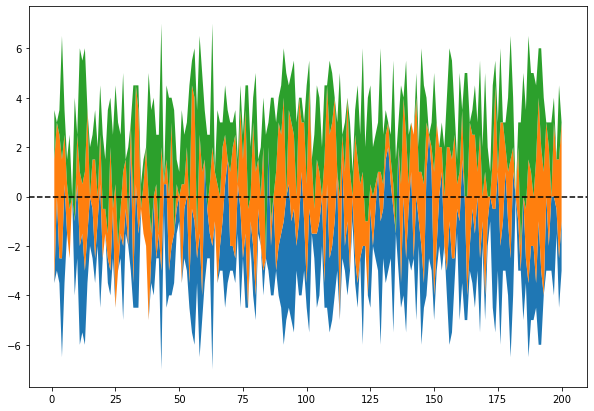

In [45]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.stackplot(x, y, baseline="sym")
ax.axhline(0, color="black", ls="--");

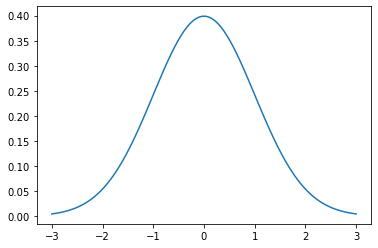

In [46]:
grid = np.linspace(-3, 3, num=100)
plt.plot(grid, stats.norm.pdf(grid));

In [47]:
def gaussian_smooth(x, y, sd):
    weights = np.array([stats.norm.pdf(x, m, sd) for m in x])
    weights = weights / weights.sum(1)
    return (weights * y).sum(1)

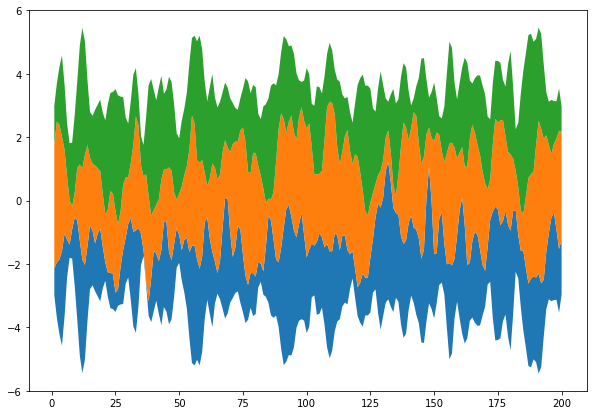

In [48]:
fig, ax = plt.subplots(figsize=(10, 7))
y_smoothed = [gaussian_smooth(x, y_, 1) for y_ in y]
ax.stackplot(x, y_smoothed, baseline="sym");